### Importación de datos



In [3]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [4]:
import matplotlib.pyplot as plt

#1. Análisis de facturación



In [5]:
# Calcular el ingreso total por cada tienda

ingresos = [
    tienda1['Precio'].sum(),
    tienda2['Precio'].sum(),
    tienda3['Precio'].sum(),
    tienda4['Precio'].sum()
]

tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Crear un DataFrame de resumen para facilitar la manipulación

df_facturacion = pd.DataFrame({
    'Tienda': tiendas,
    'Ingresos Totales': ingresos
}).sort_values(by='Ingresos Totales', ascending=False)

print("Resumen de Facturación Total:")
print(df_facturacion)

Resumen de Facturación Total:
     Tienda  Ingresos Totales
0  Tienda 1      1.150880e+09
1  Tienda 2      1.116344e+09
2  Tienda 3      1.098020e+09
3  Tienda 4      1.038376e+09


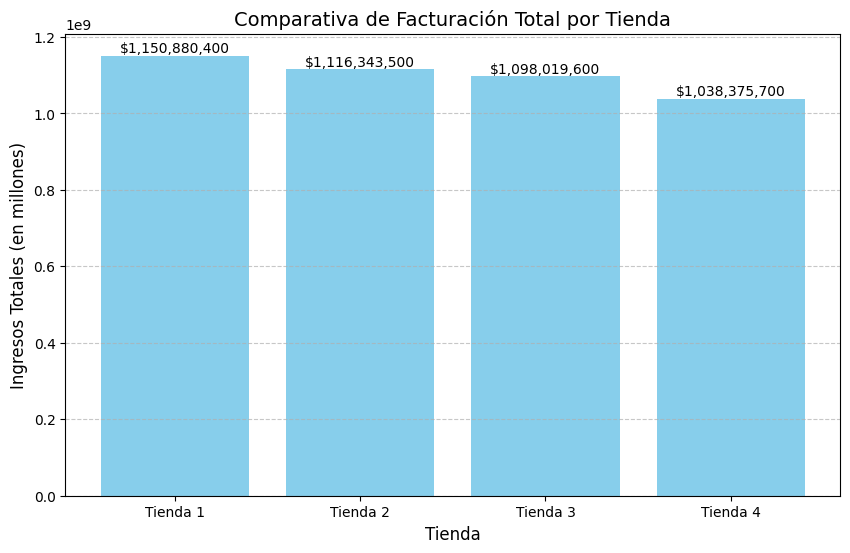

In [6]:
# Crear el gráfico de barras

plt.figure(figsize=(10, 6))
bars = plt.bar(df_facturacion['Tienda'], df_facturacion['Ingresos Totales'], color='skyblue')

plt.title('Comparativa de Facturación Total por Tienda', fontsize=14)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingresos Totales (en millones)', fontsize=12)

# Añadir etiquetas de datos sobre las barras para mayor claridad

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:,.0f}', va='bottom', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Ventas por categoría

In [7]:
# Añadir identificador de tienda
tienda1['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Concatenar todos los datos en un solo DataFrame
df_total = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)

# Agrupar por Tienda y Categoría para ver ingresos
ventas_categoria = df_total.groupby(['Tienda', 'Categoría del Producto'])['Precio'].sum().unstack().fillna(0)

print("Ingresos por Categoría y Tienda:")
display(ventas_categoria)

Ingresos por Categoría y Tienda:


Categoría del Producto,Artículos para el hogar,Deportes y diversión,Electrodomésticos,Electrónicos,Instrumentos musicales,Juguetes,Libros,Muebles
Tienda,,,,,,,,
Tienda 1,12698400.0,39290000.0,363685200.0,429493500.0,91299000.0,17995700.0,8784900.0,187633700.0
Tienda 2,14746900.0,34744500.0,348567800.0,410831100.0,104990300.0,15945400.0,10091200.0,176426300.0
Tienda 3,15060000.0,35593100.0,329237900.0,410775800.0,77380900.0,19401100.0,9498700.0,201072100.0
Tienda 4,15074500.0,33350100.0,283260200.0,409476100.0,75102400.0,20262200.0,9321300.0,192528900.0


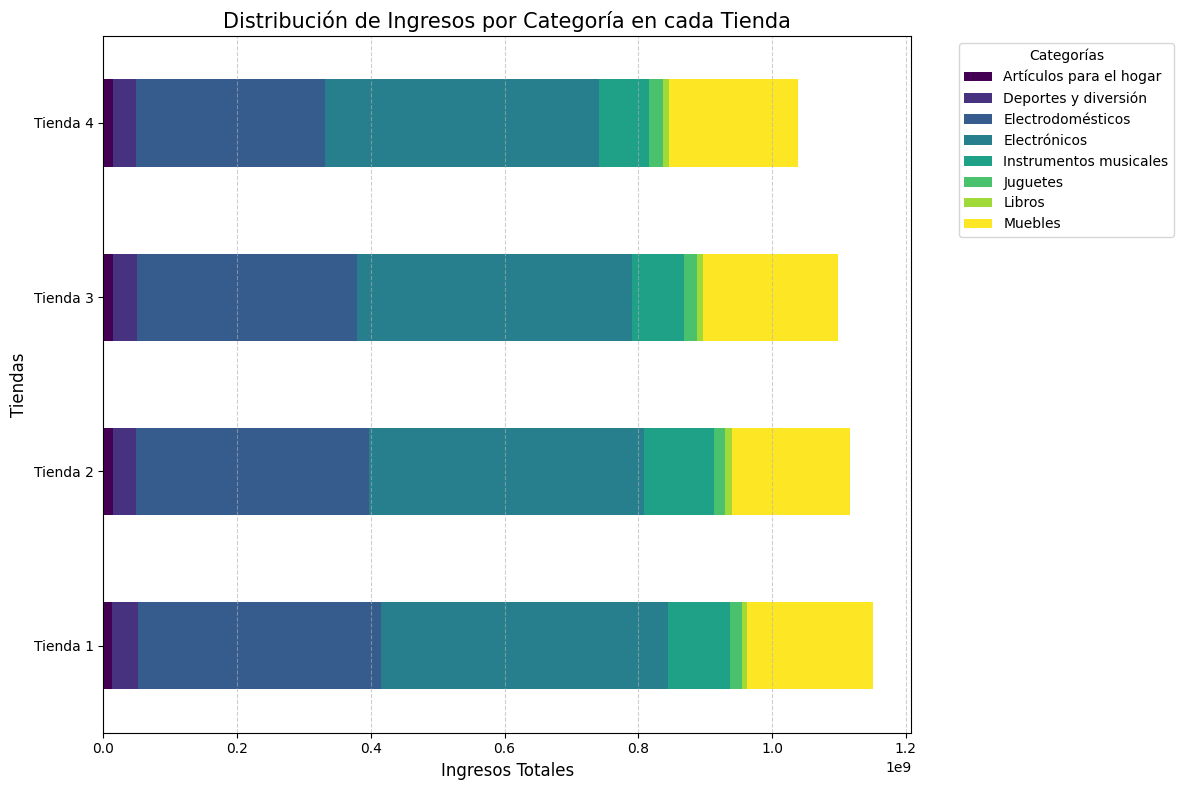

In [8]:
# Configurar el gráfico
ax = ventas_categoria.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='viridis')

# Personalización
plt.title('Distribución de Ingresos por Categoría en cada Tienda', fontsize=15)
plt.xlabel('Ingresos Totales', fontsize=12)
plt.ylabel('Tiendas', fontsize=12)
plt.legend(title='Categorías', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [9]:
# Calcular el promedio de calificación por cada tienda
promedios_calificacion = [
    tienda1['Calificación'].mean(),
    tienda2['Calificación'].mean(),
    tienda3['Calificación'].mean(),
    tienda4['Calificación'].mean()
]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Crear un DataFrame para organizar los resultados
df_calificaciones = pd.DataFrame({
    'Tienda': nombres_tiendas,
    'Calificación Promedio': promedios_calificacion
}).sort_values(by='Calificación Promedio', ascending=True) # De menor a mayor para identificar la crítica

print("Calificación Promedio por Tienda (Escala 1-5):")
print(df_calificaciones)

Calificación Promedio por Tienda (Escala 1-5):
     Tienda  Calificación Promedio
0  Tienda 1               3.976685
3  Tienda 4               3.995759
1  Tienda 2               4.037304
2  Tienda 3               4.048326


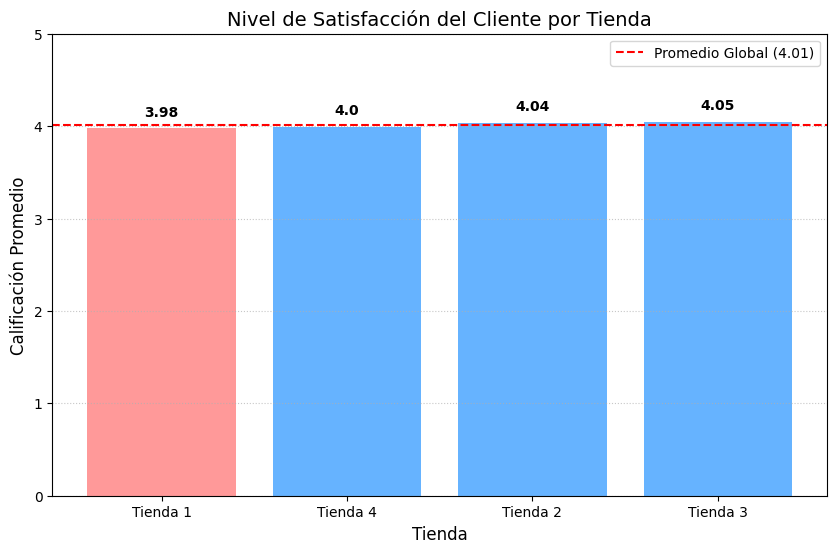

In [10]:
plt.figure(figsize=(10, 6))

# Crear el gráfico
colores = ['#ff9999' if x == df_calificaciones['Calificación Promedio'].min() else '#66b3ff' for x in df_calificaciones['Calificación Promedio']]
bars = plt.bar(df_calificaciones['Tienda'], df_calificaciones['Calificación Promedio'], color=colores)

# Personalización
plt.title('Nivel de Satisfacción del Cliente por Tienda', fontsize=14)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Calificación Promedio', fontsize=12)
plt.ylim(0, 5) # La escala de calificación es de 1 a 5

# Añadir etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), va='bottom', ha='center', fontweight='bold')

# Línea de promedio global para comparar el desempeño
promedio_global = df_calificaciones['Calificación Promedio'].mean()
plt.axhline(promedio_global, color='red', linestyle='--', label=f'Promedio Global ({round(promedio_global, 2)})')

plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

# 4. Productos más y menos vendidos

In [11]:
# Consolidar todos los productos en un solo conteo por tienda
def obtener_extremos_ventas(df, nombre_tienda):
    conteo = df['Producto'].value_counts()
    top_5 = conteo.head(5)
    bottom_5 = conteo.tail(5)
    return top_5, bottom_5

# Obtenemos los datos para cada tienda
tops = {}
bottoms = {}

for i, df in enumerate([tienda1, tienda2, tienda3, tienda4], 1):
    t, b = obtener_extremos_ventas(df, f'Tienda {i}')
    tops[f'Tienda {i}'] = t
    bottoms[f'Tienda {i}'] = b

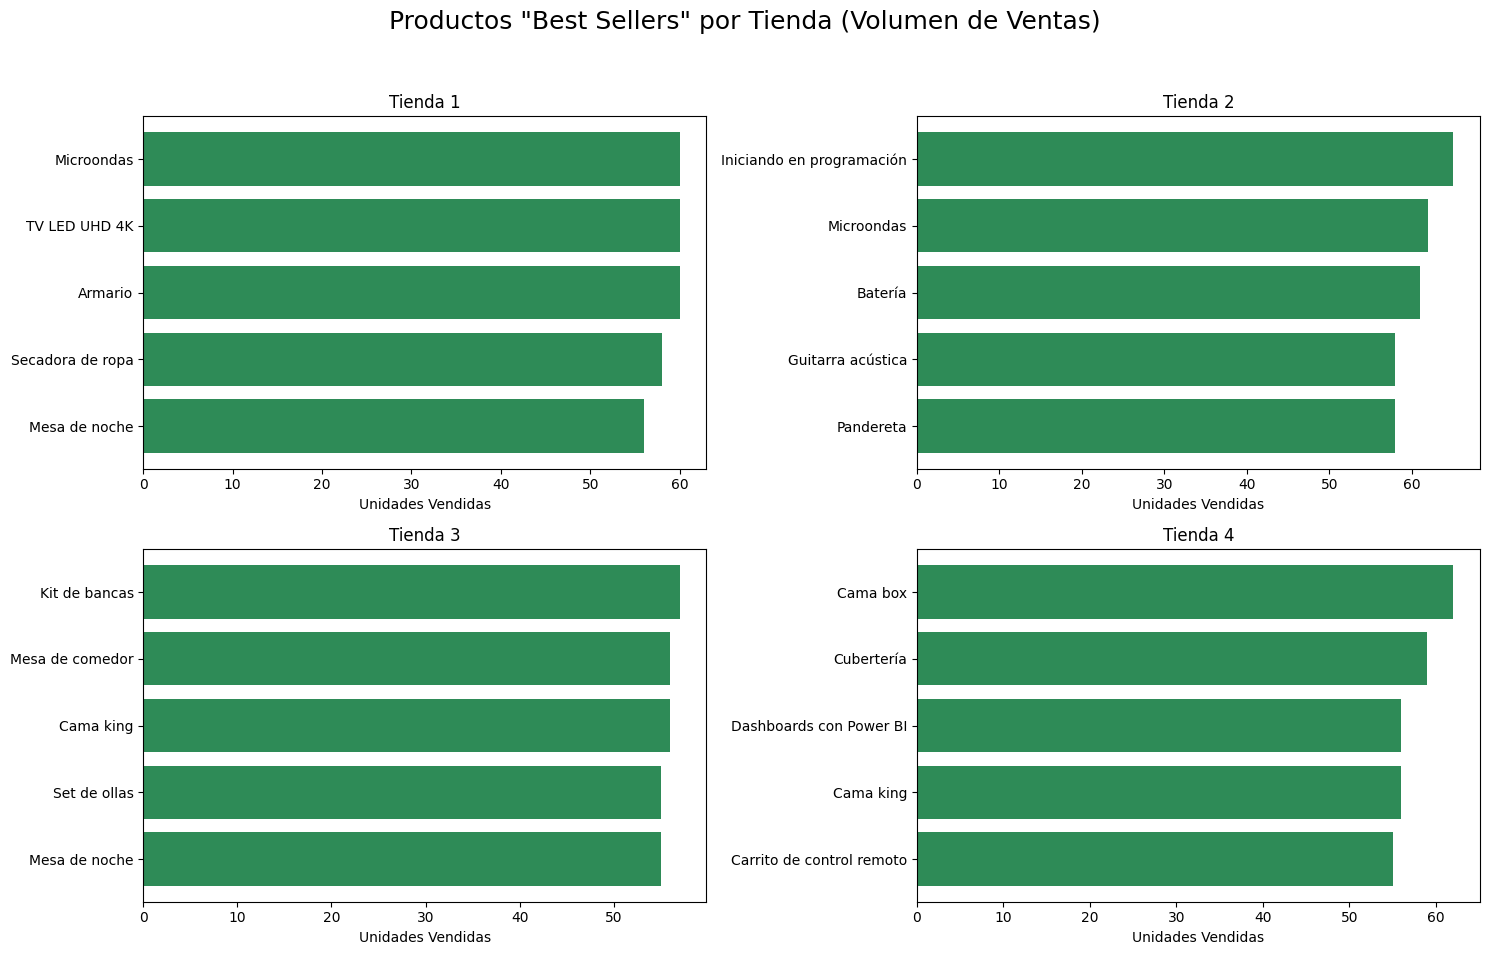

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Productos "Best Sellers" por Tienda (Volumen de Ventas)', fontsize=18)

tiendas_nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
axes = axs.flatten()

for i, nombre in enumerate(tiendas_nombres):
    data = tops[nombre]
    axes[i].barh(data.index, data.values, color='seagreen')
    axes[i].set_title(nombre)
    axes[i].invert_yaxis() # Para que el más vendido esté arriba
    axes[i].set_xlabel('Unidades Vendidas')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Envío promedio por tienda

In [13]:
# Calcular el costo de envío promedio por cada tienda
promedios_envio = [
    tienda1['Costo de envío'].mean(),
    tienda2['Costo de envío'].mean(),
    tienda3['Costo de envío'].mean(),
    tienda4['Costo de envío'].mean()
]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Crear DataFrame para el resumen logístico
df_logistica = pd.DataFrame({
    'Tienda': nombres_tiendas,
    'Costo Envío Promedio': promedios_envio
}).sort_values(by='Costo Envío Promedio', ascending=False) # De mayor a menor costo

print("Resumen de Eficiencia Logística:")
print(df_logistica)

Resumen de Eficiencia Logística:
     Tienda  Costo Envío Promedio
0  Tienda 1          26018.609580
1  Tienda 2          25216.235693
2  Tienda 3          24805.680373
3  Tienda 4          23459.457167


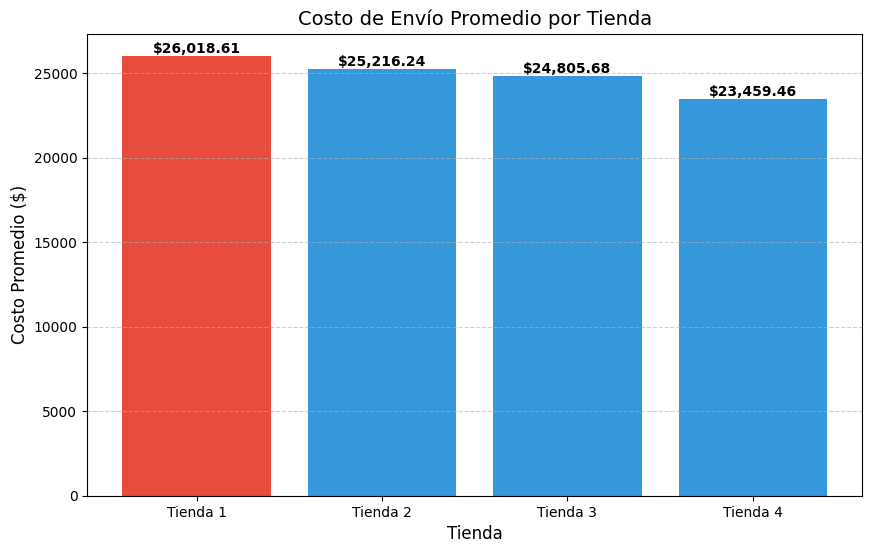

In [14]:
plt.figure(figsize=(10, 6))

# Crear el gráfico
# Usamos un color que denote "alerta" para los costos más altos
colores_log = ['#e74c3c' if x == df_logistica['Costo Envío Promedio'].max() else '#3498db' for x in df_logistica['Costo Envío Promedio']]
bars = plt.bar(df_logistica['Tienda'], df_logistica['Costo Envío Promedio'], color=colores_log)

# Personalización
plt.title('Costo de Envío Promedio por Tienda', fontsize=14)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo Promedio ($)', fontsize=12)

# Añadir etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:,.2f}', va='bottom', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 6. Análisis General por Tienda

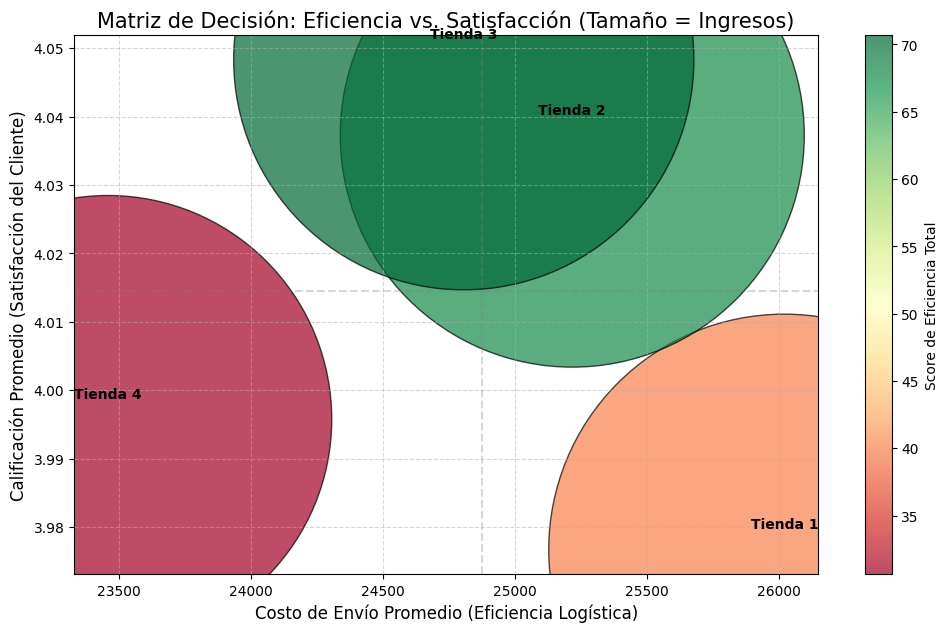

Ranking de Eficiencia:
     Tienda      Ingresos    Rating  Eficiencia_Total
3  Tienda 4  1.038376e+09  3.995759         30.649884
0  Tienda 1  1.150880e+09  3.976685         40.000000
1  Tienda 2  1.116344e+09  4.037304         67.837502
2  Tienda 3  1.098020e+09  4.048326         70.684982


In [15]:
import numpy as np

# 1. Consolidación de métricas finales
resumen_final = []
for i, df in enumerate([tienda1, tienda2, tienda3, tienda4], 1):
    resumen_final.append({
        'Tienda': f'Tienda {i}',
        'Ingresos': df['Precio'].sum(),
        'Rating': df['Calificación'].mean(),
        'Envio': df['Costo de envío'].mean()
    })

df_resumen = pd.DataFrame(resumen_final)

# 2. Cálculo de Score de Eficiencia (0 a 100)
# Normalizamos: (Valor - Min) / (Max - Min)
df_resumen['Score_Ingresos'] = (df_resumen['Ingresos'] - df_resumen['Ingresos'].min()) / (df_resumen['Ingresos'].max() - df_resumen['Ingresos'].min())
df_resumen['Score_Rating'] = (df_resumen['Rating'] - df_resumen['Rating'].min()) / (df_resumen['Rating'].max() - df_resumen['Rating'].min())
df_resumen['Score_Envio'] = 1 - (df_resumen['Envio'] - df_resumen['Envio'].min()) / (df_resumen['Envio'].max() - df_resumen['Envio'].min()) # Inverso porque menos es mejor

# Score Final ponderado: 40% Ingresos, 40% Rating, 20% Logística
df_resumen['Eficiencia_Total'] = (df_resumen['Score_Ingresos'] * 0.4 +
                                  df_resumen['Score_Rating'] * 0.4 +
                                  df_resumen['Score_Envio'] * 0.2) * 100

# 3. Gráfico de Matriz de Desempeño
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_resumen['Envio'], df_resumen['Rating'],
            s=df_resumen['Ingresos']/10000, # Tamaño proporcional a ingresos
            c=df_resumen['Eficiencia_Total'], cmap='RdYlGn', alpha=0.7, edgecolors="black")

# Anotaciones
for i, row in df_resumen.iterrows():
    plt.annotate(row['Tienda'], (row['Envio'], row['Rating']), xytext=(0,15), textcoords='offset points', ha='center', fontweight='bold')

plt.colorbar(scatter, label='Score de Eficiencia Total')
plt.title('Matriz de Decisión: Eficiencia vs. Satisfacción (Tamaño = Ingresos)', fontsize=15)
plt.xlabel('Costo de Envío Promedio (Eficiencia Logística)', fontsize=12)
plt.ylabel('Calificación Promedio (Satisfacción del Cliente)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Cuadrantes sugeridos
plt.axhline(df_resumen['Rating'].mean(), color='grey', linestyle='--', alpha=0.3)
plt.axvline(df_resumen['Envio'].mean(), color='grey', linestyle='--', alpha=0.3)

plt.show()

print("Ranking de Eficiencia:")
print(df_resumen[['Tienda', 'Ingresos', 'Rating', 'Eficiencia_Total']].sort_values(by='Eficiencia_Total'))

# 7. Decisión Final y Recomendaciones para el Sr. Juan

In [16]:
# Lista de nuestros DataFrames y sus nombres
tiendas_list = [tienda1, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

resumen_datos = []

for i, df in enumerate(tiendas_list):
    # Cálculos por tienda
    ingreso_total = df['Precio'].sum()
    calif_promedio = df['Calificación'].mean()
    total_productos = len(df)
    envio_promedio = df['Costo de envío'].mean()

    # Análisis de categorías (Frecuencia)
    conteo_categorias = df['Categoría del Producto'].value_counts()
    cat_mas_vendida = conteo_categorias.idxmax()
    cat_menos_vendida = conteo_categorias.idxmin()

    # Guardar en la lista
    resumen_datos.append({
        'Tienda': nombres[i],
        'Ingreso Total ($)': ingreso_total,
        'Calificación Promedio': round(calif_promedio, 2),
        'Productos Vendidos (Cant.)': total_productos,
        'Envío Promedio ($)': round(envio_promedio, 2),
        'Categoría Más Vendida': cat_mas_vendida,
        'Categoría Menos Vendida': cat_menos_vendida
    })

# Crear el DataFrame final
df_informe_final = pd.DataFrame(resumen_datos)

# Mostrar la tabla con formato profesional
display(df_informe_final.style.format({
    'Ingreso Total ($)': '{:,.2f}',
    'Envío Promedio ($)': '{:,.2f}'
}).highlight_max(subset=['Ingreso Total ($)', 'Calificación Promedio'], color='lightgreen')
  .highlight_min(subset=['Ingreso Total ($)', 'Calificación Promedio', 'Envío Promedio ($)'], color='#ff9999'))

,Tienda,Ingreso Total ($),Calificación Promedio,Productos Vendidos (Cant.),Envío Promedio ($),Categoría Más Vendida,Categoría Menos Vendida
0,Tienda 1,"1,150,880,400.00",3.980000,2359,"26,018.61",Muebles,Artículos para el hogar
1,Tienda 2,"1,116,343,500.00",4.040000,2359,"25,216.24",Muebles,Artículos para el hogar
2,Tienda 3,"1,098,019,600.00",4.050000,2359,"24,805.68",Muebles,Instrumentos musicales
3,Tienda 4,"1,038,375,700.00",4.000000,2358,"23,459.46",Muebles,Instrumentos musicales


Basado en el análisis de datos realizado, la recomendación técnica es la siguiente:

**Decisión:** Vender la Tienda 4.

###**Sustentación**

**Fuga de Rentabilidad:** Esta tienda presenta la menor rentabilidad de entre las 4, lo que el primer aspecto a señalar como establecimiento que afecta negativamente a la marca de acuerdo a los siguientes aspectos por ver.



**Riesgo Reputacional:** Posee la segunda Calificación Promedio más baja del portafolio. Si bien no es el último puesto, esto sugiere que retenerla implica un "costo de remediación" alto (necesidad de invertir en servicio al cliente o calidad de producto) para evitar que dañe la marca Alura Store.

**Costo de Oportunidad:** Al ser la tienda con menor Score de Eficiencia Total, es el activo que menos valor aporta al ecosistema del Sr. Juan. Su venta proporcionará el capital necesario para el nuevo emprendimiento sin sacrificar las unidades que sí demuestran tracción y satisfacción del cliente.